In [2]:
#Data import & EDA 
import pandas as pd
df = pd.read_csv("Tweets.csv")
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
df.columns

Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
       'negativereason', 'negativereason_confidence', 'airline',
       'airline_sentiment_gold', 'name', 'negativereason_gold',
       'retweet_count', 'text', 'tweet_coord', 'tweet_created',
       'tweet_location', 'user_timezone'],
      dtype='str')

In [4]:
df.shape

(14640, 15)

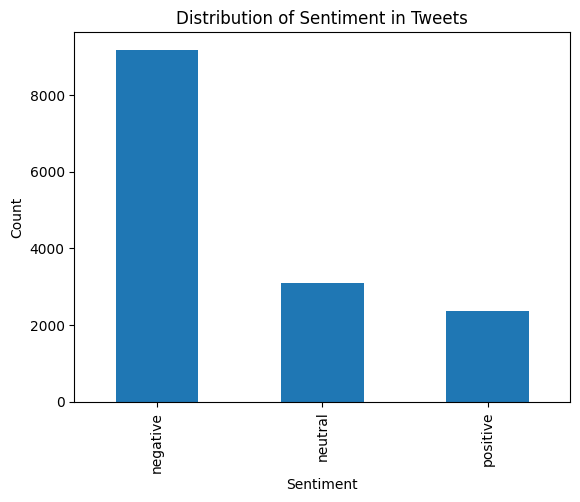

In [5]:
import matplotlib.pyplot as plt

df['airline_sentiment'].value_counts().plot(kind='bar')

plt.title("Distribution of Sentiment in Tweets")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

In [7]:
#) Text preprocessing 
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_text"] = df["text"].apply(clean_text)

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone,clean_text
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),virginamerica dhepburn said
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),virginamerica plus youve added commercials exp...
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),virginamerica didnt today mean need trip
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),virginamerica really aggressive blast obnoxiou...
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),virginamerica really big bad thing


In [8]:
#  Topic modeling (
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_features=1000)

X = vectorizer.fit_transform(df["clean_text"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)

lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [11]:
# Import libraries
from sklearn.feature_extraction.text import CountVectorizer

# Convert cleaned tweets into numeric vectors
vectorizer = CountVectorizer(max_features=1000)
X = vectorizer.fit_transform(df["clean_text"])

# Getting vocabulary
words = vectorizer.get_feature_names_out()
print("Sample Vocabulary (first 10 words):")
print(words[:10])


# Showing document-term matrix for first 5 tweets and first 10 words
print("\nDocument-Term Matrix (first 5 tweets × first 10 words):")
print(X[:5, :10].toarray())

Sample Vocabulary (first 10 words):
['aa' 'able' 'absolute' 'absolutely' 'acceptable' 'access' 'account'
 'actual' 'actually' 'add']

Document-Term Matrix (first 5 tweets × first 10 words):
[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [13]:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):

    print(f"Topic {i}")

    print([words[i] for i in topic.argsort()[-10:]])

Topic 0
['guys', 'love', 'just', 'thanks', 'great', 'jetblue', 'virginamerica', 'thank', 'united', 'southwestair']
Topic 1
['dont', 'jfk', 'fly', 'thanks', 'im', 'home', 'just', 'usairways', 'flight', 'jetblue']
Topic 2
['southwestair', 'help', 'hours', 'cancelled', 'customer', 'flight', 'service', 'hold', 'usairways', 'americanair']
Topic 3
['thanks', 'flights', 'southwestair', 'time', 'flightled', 'delayed', 'late', 'cancelled', 'flight', 'united']
Topic 4
['hour', 'help', 'number', 'aa', 'plane', 'thanks', 'gate', 'flight', 'usairways', 'americanair']


In [13]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Assuming you already have:
# df["clean_text"], vectorizer, and lda fitted

# Get vocabulary
words = vectorizer.get_feature_names_out()

# Collect top 10 words per topic
topic_words = []
for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-10:]]  # top 10 words
    topic_words.append(top_words)

interpretations = [
    "Positive feedback / praise",
    "Flight info / neutral tweets",
    "Complaints / customer service issues",
    "Flight delays / operational issues",
    "Airport assistance / queries"
]


topic_df = pd.DataFrame({
    "Topic": [f"Topic {i}" for i in range(len(topic_words))],
    "Top Words": [", ".join(words) for words in topic_words],
    "Interpretation": interpretations
})


print(topic_df)

topic_df.to_csv("lda_topic_summary.csv", index=False)



     Topic                                          Top Words  \
0  Topic 0  guys, love, just, thanks, great, jetblue, virg...   
1  Topic 1  dont, jfk, fly, thanks, im, home, just, usairw...   
2  Topic 2  southwestair, help, hours, cancelled, customer...   
3  Topic 3  thanks, flights, southwestair, time, flightled...   
4  Topic 4  hour, help, number, aa, plane, thanks, gate, f...   

                         Interpretation  
0            Positive feedback / praise  
1          Flight info / neutral tweets  
2  Complaints / customer service issues  
3    Flight delays / operational issues  
4          Airport assistance / queries  


In [15]:
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install groq

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 8.3 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.3
    Uninstalling pip-25.3:
      Successfully uninstalled pip-25.3


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 14.4 MB/s  0:00:00

   ----- ----------------------------------  2/14 [idna]
   ----- ----------------------------------  2/14 [idna]
   -------- -------------------------------  3/14 [h11]
   -------- -------------------------------  3/14 [h11]
   -------------- -------------------------  5/14 [certifi]
   -------------------- -------------------  7/14 [typing-inspection]
   ------------------------- --------------  9/14 [httpcore]
   ------------------------- --------------  9/14 [httpcore]
   ------------------------- --------------  9/14 [httpcore]
   ------------------------- --------------  9/14 [httpcore]
   ------------------------- --------------  9/14 [httpcore]
   ---------------------------- ----------- 10/14 [anyio]
   ---------------------------- ----------- 10/14 [anyio]
   ---------------------------- ----------- 10/14 [anyio]
   ------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [16]:
# sentiment analysis using google AI studio
sample_tweets = df["text"].sample(10, random_state=42).reset_index(drop=True)


for i, tweet in enumerate(sample_tweets, 1):
    print(f"{i}. {tweet}\n")

1. @SouthwestAir you're my early frontrunner for best airline! #oscars2016

2. @USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?

3. @JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?

4. @JetBlue do they have to depart from Washington, D.C.??

5. @JetBlue I can probably find some of them. Are the ticket #s on there?

6. @united still waiting to hear back. My wallet was stolen from one of your planes so would appreciate a resolution here

7. @united Yes my flight was rebooked. I'm just losing trust in you if I want to get anywhere on time.

8. @JetBlue Thank you ! What about Paris ? Could we arrange something from there ?

9. @united not 100% sure, however my ticket included one checked bag, therefore this charge was extra and completely unanticipated.

10. @usairways great crew for flight 504 PHX to YVR tonight! Friendly, efficient. Awesome job.



LLM Sentiment Analysis Sample Results:



,Tweet,LLM Sentiment
0,@SouthwestAir you're my early frontrunner for ...,Positive
1,@USAirways how is it that my flt to EWR was Ca...,Negative
2,@JetBlue what is going on with your BDL to DCA...,Negative
3,@JetBlue do they have to depart from Washingto...,Neutral
4,@JetBlue I can probably find some of them. Are...,Neutral
5,@united still waiting to hear back. My wallet ...,Negative
6,@united Yes my flight was rebooked. I'm just l...,Negative
7,@JetBlue Thank you ! What about Paris ? Could ...,Positive
8,"@united not 100% sure, however my ticket inclu...",Negative
9,@usairways great crew for flight 504 PHX to YV...,Positive


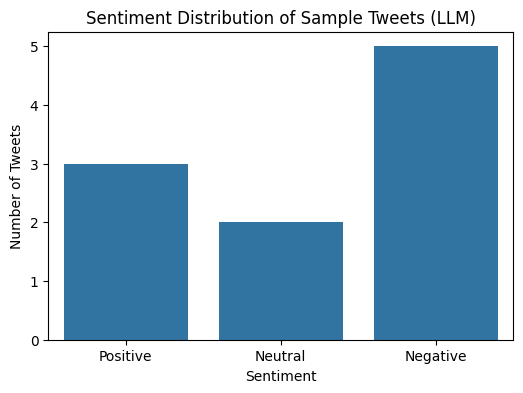

In [17]:
# LLM Sentiment Analysis Results

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tweets and their LLM sentiment labels
tweets = [
    "@SouthwestAir you're my early frontrunner for best airline! #oscars2016",
    "@USAirways how is it that my flt to EWR was Cancelled Flightled yet flts to NYC from USAirways are still flying?",
    "@JetBlue what is going on with your BDL to DCA flights yesterday and today?! Why is every single one getting delayed?",
    "@JetBlue do they have to depart from Washington, D.C.??",
    "@JetBlue I can probably find some of them. Are the ticket #s on there?",
    "@united still waiting to hear back. My wallet was stolen from one of your planes so would appreciate a resolution here",
    "@united Yes my flight was rebooked. I'm just losing trust in you if I want to get anywhere on time.",
    "@JetBlue Thank you ! What about Paris ? Could we arrange something from there ?",
    "@united not 100% sure, however my ticket included one checked bag, therefore this charge was extra and completely unanticipated.",
    "@usairways great crew for flight 504 PHX to YVR tonight! Friendly, efficient. Awesome job."
]

sentiments = [
    "Positive", "Negative", "Negative", "Neutral", "Neutral",
    "Negative", "Negative", "Positive", "Negative", "Positive"
]

#  DataFrame
llm_df = pd.DataFrame({"Tweet": tweets, "LLM Sentiment": sentiments})

# Display the DataFrame
print("LLM Sentiment Analysis Sample Results:\n")
display(llm_df)

# Plot sentiment distribution
plt.figure(figsize=(6,4))
sns.countplot(x='LLM Sentiment', data=llm_df, order=['Positive','Neutral','Negative'])
plt.title("Sentiment Distribution of Sample Tweets (LLM)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.show()

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use cleaned text column
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity matrix
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [20]:
# Knowledge-based recommender
def recommend_similar_tweets(query_index, top_n=10):
    # Get similarity scores for the query tweet
    sim_scores = list(enumerate(cosine_sim[query_index]))
    
    # Sort by similarity score in descending order
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Exclude the query tweet itself (first result)
    sim_scores = sim_scores[1:top_n+1]
    
    # Get tweet indices
    tweet_indices = [i[0] for i in sim_scores]
    
    # Return top n similar tweets
    return df.iloc[tweet_indices][["text", "airline_sentiment"]]

# Example: get 10 tweets similar to tweet at index 0
recommend_similar_tweets(0, top_n=10)

,text,airline_sentiment
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",positive
46,@VirginAmerica DREAM http://t.co/oA2dRfAoQ2 h...,neutral
49,@VirginAmerica @ladygaga @carrieunderwood All ...,neutral
53,@VirginAmerica @ladygaga @carrieunderwood Juli...,neutral
58,@VirginAmerica @ladygaga @carrieunderwood - Ca...,neutral
138,@VirginAmerica always!!! Xoxo,positive
169,@VirginAmerica to jump into the Dallas-Austin ...,neutral
234,@VirginAmerica Very nicely done. 👏,positive
241,@virginamerica spruce moose!,neutral
255,"@VirginAmerica beats expectations, shares take...",neutral


In [21]:
# Step 3: Simple stopword list
stop_words = set([
    "i","me","my","myself","we","our","ours","ourselves","you","your","yours",
    "yourself","yourselves","he","him","his","himself","she","her","hers","herself",
    "it","its","itself","they","them","their","theirs","themselves","what","which",
    "who","whom","this","that","these","those","am","is","are","was","were","be","been",
    "being","have","has","had","having","do","does","did","doing","a","an","the","and",
    "but","if","or","because","as","until","while","of","at","by","for","with","about",
    "against","between","into","through","during","before","after","above","below","to",
    "from","up","down","in","out","on","off","over","under","again","further","then",
    "once","here","there","when","where","why","how","all","any","both","each","few",
    "more","most","other","some","such","no","nor","not","only","own","same","so",
    "than","too","very","s","t","can","will","just","don","should","now"
])

In [22]:
# Apply your clean_text function to the dataset
df["clean_text"] = df["text"].apply(clean_text)

# Quick check
df[["text", "clean_text"]].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,virginamerica dhepburn said
1,@VirginAmerica plus you've added commercials t...,virginamerica plus youve added commercials exp...
2,@VirginAmerica I didn't today... Must mean I n...,virginamerica didnt today must mean need take ...
3,@VirginAmerica it's really aggressive to blast...,virginamerica really aggressive blast obnoxiou...
4,@VirginAmerica and it's a really big bad thing...,virginamerica really big bad thing


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Convert all tweets to TF-IDF vectors
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["clean_text"])

# Compute similarity between all tweets
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [24]:
def recommend_similar_tweets(query_text, top_n=10):
    # Clean query text
    query_clean = clean_text(query_text)
    
    # Vectorize query
    query_vec = tfidf_vectorizer.transform([query_clean])
    
    # Compute similarity with all dataset tweets
    sim_scores = cosine_similarity(query_vec, tfidf_matrix)[0]
    
    # Get top_n most similar tweets
    top_indices = sim_scores.argsort()[::-1][:top_n]
    
    # Return tweet text and sentiment
    return df.iloc[top_indices][["text", "airline_sentiment"]]

In [25]:
# Example test query
query_tweet = "@JetBlue my flight was delayed and customer service was unhelpful"

# Get top 10 similar tweets
similar_tweets = recommend_similar_tweets(query_tweet, top_n=10)
similar_tweets

,text,airline_sentiment
1728,@united so unhelpful... http://t.co/vBfIeo2qJC,negative
7675,@JetBlue I am But Your customer service is Bru...,negative
8231,@JetBlue delayed flight bummer,negative
8863,@JetBlue why are we delayed :( flight 1601,negative
10060,@USAirways not impressed with your customer se...,negative
1496,"@United ""delayed due to customer service"" Huh?...",negative
7573,@JetBlue Thanks for the personalized customer ...,positive
8820,@JetBlue @EllaHenderson the highlight of being...,negative
8819,"@JetBlue we are delayed, until he arrives",negative
963,@united this is atrocious customer service.,negative


In [26]:
import pandas as pd

# Show full column content 
pd.set_option('display.max_colwidth', None)

# Now display your DataFrame
df[["text", "airline_sentiment"]].head(10)

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials to the experience... tacky.,positive
2,@VirginAmerica I didn't today... Must mean I need to take another trip!,neutral
3,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",negative
4,@VirginAmerica and it's a really big bad thing about it,negative
5,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\r\nit's really the only bad thing about flying VA,negative
6,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",positive
7,"@VirginAmerica Really missed a prime opportunity for Men Without Hats parody, there. https://t.co/mWpG7grEZP",neutral
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",positive
9,"@VirginAmerica it was amazing, and arrived an hour early. You're too good to me.",positive


In [27]:
# Example test query
query_tweet = "@Delta really impressed with the crew and smooth boarding process! "

# Get top 10 similar tweets
similar_tweets = recommend_similar_tweets(query_tweet, top_n=10)
similar_tweets

,text,airline_sentiment
7967,@JetBlue were boarding now I'm really not impressed. I've learnt a very valuable lesson .,negative
7969,.@JetBlue process begins 6:48,neutral
1343,@united I am impressed with your super-fast reply to @CGJase,positive
3270,@united Your boarding process sucks. You should learn from @SouthwestAir,negative
14299,"As am I, @AmericanAir - but thankfully there was a @united lounge next door. Really not impressed by oneworld partnerships :(",negative
14187,@AmericanAir I am honestly in shock how this process and service compares to my other airline experiences. Not really sure what to say...,negative
12063,.@AmericanAir just disappointed with the Flight Booking Problems process and add’l fees to sit together on a more crowded flight. Not impressed so far :-/.,neutral
11902,.@AmericanAir just disappointed with the Flight Booking Problems process and add’l fees to sit together on a more crowded flight. Not impressed so far :-/.,neutral
1327,"@united - 75% of a plane's passengers boarding in your ""Premier"" groups might be an indication of a broken process.",negative
8154,@JetBlue the slowest boarding process I've ever experienced and rude customer service agents.,negative
